<!-- SPDX-FileCopyrightText: 2026 Orbital Research Cluster for Celestial Applications (ORCCA) Lab, University of Colorado at Boulder -->
<!-- SPDX-License-Identifier: ISC -->
# Sequential Orbit Determination — Complete Demo
---
*Scarabaeus OD Framework | Last revised 2026*

## What this notebook covers
Sequential orbit determination processes measurements **one at a time** (or batch-by-batch),
updating the state estimate and covariance recursively.  This is operationally efficient,
supports real-time processing, and naturally handles process noise through the filter equations.

### Topics
| # | Topic |
|---|-------|
| 1 | Setup, spacecraft, and true trajectory |
| 2 | Measurement generation |
| 3 | LKF (Linearized Kalman Filter) with SNC process noise |
| 4 | Process noise deep dive — SNC vs. DMC |
| 5 | First-Order Gauss-Markov (FOGM) dynamics + DMC process noise |
| 6 | SRIF (Square-Root Information Filter) |
| 7 | RTS smoother |
| 8 | Multi-leg OD with MissionSequence (two legs + impulsive burn) |
| 9 | Consider parameters |
| 10 | Measurement editing in sequential context |
| 11 | Solution saving and full analysis |

## How to run
Run from the **project root** directory (`scarabaeus/`).


## 0. Imports and Setup

In [1]:
import os, sys
import numpy as np
import numpy.random as rnd
import matplotlib.pyplot as plt
import scarabaeus as scb

# Navigate to project root
if os.path.basename(os.getcwd()) == 'tutorials':
    os.chdir('..')
print(f"Working directory : {os.getcwd()}")

os.makedirs('data/measurements/radiometric', exist_ok=True)
os.makedirs('data/kernels/scenario',         exist_ok=True)

kg, km, sec = scb.Units.get_units(['kg', 'km', 'sec'])
J2000, ITRF93, ECLIPJ2000, IAUEARTH = scb.Frame.generate_common_frames()
frame  = J2000
origin = scb.CelestialBody.from_constants('SUN')

mk = os.path.join('data', 'kernels', 'locked', 'locked_generic.tm')
scb.SpiceManager.clear_kernels()
scb.SpiceManager.load_kernel_from_mkfile(mk)
print("Kernels loaded.")

# ── common spacecraft & initial state ────────────────────────────
dry_mass  = scb.ArrayWUnits(1500.0, kg)
fuel_mass = scb.ArrayWUnits(500.0,  kg)
area      = scb.ArrayWUnits(1e-6,   km**2)
cr        = scb.ArrayWUnits(1.5,    None)

Orbiter = scb.Spacecraft('Orbiter_True', -2000,
                          dry_mass+fuel_mass, area, cr)

time_0      = scb.SpiceManager.jd2et(2461809.72995654 + 1/3)
time_f      = scb.SpiceManager.jd2et(2461809.72995654 + 3)
dt_step     = 30 * 60
epoch_array = scb.EpochArray(np.arange(time_0, time_f, dt_step), time_frame='TDB')
epoch_0     = epoch_array[0]

pos_0 = scb.ArrayWFrame(
    np.array([-1.1123095885148e+08, 8.9094345479316e+07, 3.8656500948069e+07]),
    km, frame)
vel_0 = scb.ArrayWFrame(
    np.array([-20.6936999825159, -16.7800270812616, -6.6437327193572]),
    km/sec, frame)


Working directory : /Users/zael5647/scarabaeus/docs/online_documentation/sphinx_files/_collections


SpiceNOSUCHFILE: 
================================================================================

Toolkit version: CSPICE_N0067

SPICE(NOSUCHFILE) --

The first file '../data/kernels/locked/ck/cas00084.tsc' specified by KERNELS_TO_LOAD in the file data/kernels/locked/locked_generic.tm could not be located.

furnsh_c --> FURNSH --> ZZLDKER

================================================================================

## Enhanced Plotting Helpers

The cells below add **calendar-date x-axis** versions of the plots above, plus new
visualization types: pre/post residual comparisons, state errors with ±3σ covariance
bounds, covariance evolution, and corner covariance plots.

Helper functions:
- `et2dt(et_arr)` — converts SPICE ET (seconds) to Python `datetime` objects
- `fmt_cal(ax)` — applies `AutoDateLocator + DateFormatter` for a clean calendar x-axis
- `add_hrs_axis(ax)` — adds a secondary top x-axis in hours from t0
- `resid_from_filter(flt, ds)` — extracts `(t_pre, r_pre, t_post, r_post)` arrays
- `corner_cov(P, labels)` — lower-triangle corner plot with RdBu_r correlation colouring


In [2]:
from datetime import datetime
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib import cm
from matplotlib.colors import Normalize

plt.rcParams.update({
    'font.size': 10, 'axes.titlesize': 11, 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 8,
    'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.35, 'grid.linestyle': '--',
})
CMAP = cm.tab10
COLORS = [CMAP(i / 10) for i in range(10)]

# reference epoch for the hours-from-t0 secondary axis
t0_et = float(epoch_array[0])


def et2dt(et_arr):
    """Convert SPICE ET seconds to list of datetime objects."""
    out = []
    for t in np.atleast_1d(et_arr):
        s = scb.SpiceManager.et2utc(float(t))
        try:
            parts = s.split()
            s2 = f"{parts[0]} {parts[1].capitalize()} {int(parts[2]):02d} {parts[3][:8]}"
            out.append(datetime.strptime(s2, "%Y %b %d %H:%M:%S"))
        except Exception:
            out.append(datetime(2021, 1, 1))
    return out


def fmt_cal(ax):
    """Apply calendar-date tick formatting to a matplotlib axis."""
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=4, maxticks=9))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d\n%H:%M"))


def add_hrs_axis(ax, t0=None):
    """Add a secondary top x-axis showing hours from t0."""
    t0 = t0 if t0 is not None else t0_et
    from matplotlib.dates import date2num
    t0_num = date2num(et2dt([t0])[0])
    ax2 = ax.secondary_xaxis(
        "top",
        functions=(lambda x: (x - t0_num) * 24, lambda x: x / 24 + t0_num),
    )
    ax2.set_xlabel("Hours from t0 [TDB]", fontsize=8)
    ax2.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f h"))
    return ax2


def resid_from_filter(flt_obj, ds_name):
    """Return (t_pre, r_pre, t_post, r_post) numpy arrays for a dataset name.

    Times are read from flt_obj.measurement_data (per-dataset t2 column).
    Residual values come from the [res, sigma] entries in pre/postfit_residuals.
    """
    pre  = flt_obj.prefit_residuals.get(ds_name, [])
    post = flt_obj.postfit_residuals.get(ds_name, [])
    # Retrieve t2 epochs for this dataset from the filter's measurement data
    t_ds = np.array([])
    for ds in flt_obj.measurement_data.datasets:
        if ds.set_name == ds_name:
            t_ds = np.array(ds.data["t2"])
            break
    t_pre  = t_ds[:len(pre)]  if len(pre)  else np.array([])
    r_pre  = np.array([d[0] for d in pre])  if pre  else np.array([])
    t_post = t_ds[:len(post)] if len(post) else np.array([])
    r_post = np.array([d[0] for d in post]) if post else np.array([])
    return t_pre, r_pre, t_post, r_post


def corner_cov(P, labels, title="Covariance Corner Plot", figsize=(9, 8)):
    """Lower-triangle corner plot.  Diagonal: 1-sigma.  Off-diagonal: correlation."""
    n    = P.shape[0]
    sig  = np.sqrt(np.diag(P))
    Corr = P / np.outer(sig, sig)
    fig, axes = plt.subplots(n, n, figsize=figsize)
    if n == 1:
        axes = np.array([[axes]])
    fig.suptitle(title, fontsize=11, fontweight="bold")
    cmap_r = cm.RdBu_r
    for i in range(n):
        for j in range(n):
            ax = axes[i, j]
            ax.set_xticks([]); ax.set_yticks([])
            if i == j:
                ax.set_facecolor("#dbeafe")
                ax.text(0.5, 0.62, f"1σ = {sig[i]:.2e}", ha="center", va="center",
                        transform=ax.transAxes, fontsize=6.5, fontweight="bold")
                ax.text(0.5, 0.32, labels[i], ha="center", va="center",
                        transform=ax.transAxes, fontsize=6.5, color="navy")
            elif i > j:
                c = float(Corr[i, j])
                ax.set_facecolor(cmap_r((c + 1) / 2))
                ax.text(0.5, 0.5, f"{c:+.2f}", ha="center", va="center",
                        transform=ax.transAxes, fontsize=7.5,
                        color="white" if abs(c) > 0.6 else "black")
            else:
                ax.set_visible(False)
    sm = cm.ScalarMappable(cmap=cmap_r, norm=Normalize(-1, 1)); sm.set_array([])
    fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.01, shrink=0.6, label="Correlation")
    plt.tight_layout()
    return fig


print(f"Plotting helpers ready.  t0 = {scb.SpiceManager.et2utc(t0_et)}")


NameError: name 'epoch_array' is not defined

## 1. True Trajectory and Measurements

We propagate the truth and generate Range + RangeRate measurements on it (DSS-14).
These are the "observed" measurements the filter will try to explain.

The measurement generation is identical to the Batch notebook — see that notebook for the full
measurement-model catalogue (Doppler, DDOR, optical navigation).


In [3]:
# ── propagate truth ──────────────────────────────────────────────
third_bodies = ['MERCURY', 'VENUS', 'EARTH']

state_truth = scb.StateDefinition.from_components([
    ('position', 3, 'estimated', 'dynamic', Orbiter, pos_0),
    ('velocity', 3, 'estimated', 'dynamic', Orbiter, vel_0),
])
sv_truth = scb.StateArray(epoch=epoch_0, origin=origin, state=state_truth)
fm_truth = scb.ForceModelTranslation(primary_body=Orbiter,
                                      third_bodies=third_bodies, cannonball_SRP=True)
prop_truth = scb.Propagator(primary_body=Orbiter, state_vector=sv_truth,
                             tspan=epoch_array, force_models=fm_truth)
prop_truth.propagate()
state_prop_truth = prop_truth.propagated_state_array

true_spk = 'data/kernels/scenario/seq_orbiter_true.bsp'
if os.path.isfile(true_spk): os.remove(true_spk)
orbiter_traj_true = scb.Trajectory(state_array=state_prop_truth)
orbiter_traj_true.write_to_spk(true_spk)
print(f"True trajectory saved.")

# ── generate measurements ─────────────────────────────────────────
GS1           = scb.GroundStation('DSS-14')
range_sigma   = scb.ArrayWUnits(1e-3,  km)
rr_sigma      = scb.ArrayWUnits(1e-5,  km/sec)
Range_GS1     = scb.RangeIdeal('GS1 Range',    GS1, sigma=range_sigma)
RangeRate_GS1 = scb.RangeRateIdeal('GS1 RRate', GS1, sigma=rr_sigma)

Range_GS1.write_observed_measurements(
    target=Orbiter, epoch_array=epoch_array, noisy=True, file_name='seq_range_GS1')
RangeRate_GS1.write_observed_measurements(
    target=Orbiter, epoch_array=epoch_array, noisy=True, file_name='seq_rr_GS1')

obs_range = Range_GS1.observed_measurements(
    file_name='data/measurements/radiometric/seq_range_GS1.json',
    meas_name='meas_ideal', units=km)
obs_rr    = RangeRate_GS1.observed_measurements(
    file_name='data/measurements/radiometric/seq_rr_GS1.json',
    meas_name='meas_ideal', units=km/sec)

print(f"Range measurements   : {len(obs_range[2])}")
print(f"RangeRate measurements: {len(obs_rr[2])}")


NameError: name 'Orbiter' is not defined

## 2. LKF with SNC Process Noise

### Theory
The **Linearized Kalman Filter (LKF)** is the core sequential estimator.
At each measurement epoch $t_k$:

1. **Time update (predict):** propagate state and covariance forward with the STM
   $$\mathbf{P}_{k|k-1} = \mathbf{\Phi}_{k,k-1}\,\mathbf{P}_{k-1|k-1}\,\mathbf{\Phi}_{k,k-1}^T + \mathbf{Q}_k$$

2. **Measurement update (correct):** incorporate new measurement $y_k$
   $$\mathbf{K}_k = \mathbf{P}_{k|k-1}\,\mathbf{H}_k^T\,(\mathbf{H}_k\mathbf{P}_{k|k-1}\mathbf{H}_k^T + \mathbf{R}_k)^{-1}$$
   $$\hat{\mathbf{x}}_{k|k} = \hat{\mathbf{x}}_{k|k-1} + \mathbf{K}_k(y_k - \mathbf{H}_k\hat{\mathbf{x}}_{k|k-1})$$

### State Noise Compensation (SNC)
SNC models uncharacterised accelerations as **white noise** added continuously to the velocity:

$$\mathbf{Q}_k = \int_{t_{k-1}}^{t_k} \mathbf{\Phi}(t_k,\tau)\,\mathbf{B}\,q_c\,\mathbf{B}^T\,\mathbf{\Phi}(t_k,\tau)^T\,d\tau$$

where $q_c$ [km²/s³] is the **continuous-time noise spectral density**.

**Tuning Q_cont (SNC):**
- Too large → wide covariance, accepts noise, position sigma grows fast.
- Too small → filter stiffens, can't track maneuvers or unmodelled forces.
- Rule of thumb: $q_c \approx (\text{expected unmodelled accel})^2 / \text{arc length in sec}$

```python
Q_cont = scb.ProcessNoiseSettings(type='SNC', Q_cont=Q_cont_matrix)
```


In [4]:
# ── reference spacecraft (perturbed IC) ──────────────────────────
delta_pos_km  = np.array([1.0, 1.0, 1.0])
delta_vel_kms = np.array([1e-3, 1e-3, 1e-3])

def make_ref_sc(name, spice_id, d_pos, d_vel):
    sc  = scb.Spacecraft(name, spice_id, dry_mass+fuel_mass, area, cr)
    pos = scb.ArrayWFrame(pos_0.quantity + scb.ArrayWUnits(d_pos, km), frame)
    vel = scb.ArrayWFrame(vel_0.quantity + scb.ArrayWUnits(d_vel, km/sec), frame)
    return sc, pos, vel

sc_lkf, pos_lkf, vel_lkf = make_ref_sc('Orbiter_LKF', -2001,
                                         delta_pos_km, delta_vel_kms)

state_lkf = scb.StateDefinition.from_components([
    ('position', 3, 'estimated', 'dynamic', sc_lkf, pos_lkf),
    ('velocity', 3, 'estimated', 'dynamic', sc_lkf, vel_lkf),
])
sv_lkf = scb.StateArray(epoch=epoch_0, origin=origin, state=state_lkf)

fm_lkf = scb.ForceModelTranslation(
    primary_body=sc_lkf, third_bodies=third_bodies, cannonball_SRP=True)
prop_lkf = scb.Propagator(
    primary_body=sc_lkf, state_vector=sv_lkf,
    tspan=epoch_array, force_models=fm_lkf)

# ── initial covariance ────────────────────────────────────────────
pos_sig = scb.ArrayWUnits(3.0,   km)
vel_sig = scb.ArrayWUnits(3e-3,  km/sec)
P0 = scb.CovarianceMatrix(
    [pos_sig]*3 + [vel_sig]*3, epoch_array[1], from_list=True)

# ── SNC process noise ─────────────────────────────────────────────
# q_c = (1e-9 km/s²)² = 1e-18 km²/s⁴  per axis — light SNC for well-modelled dynamics
Q_diag = scb.ArrayWUnits(1e-9**2, km**2 * sec**-4)
Q_cont = scb.CovarianceMatrix([Q_diag]*3, epoch_array[0], from_list=True)
pn_snc = scb.ProcessNoiseSettings(type='SNC', Q_cont=Q_cont)

# ── measurement list ─────────────────────────────────────────────
meas_lkf = scb.MeasurementSpec.many(
    scb.MeasurementSpec(model=Range_GS1,     observed_meas=obs_range,
                        dataset_name='GS1 Range'),
    scb.MeasurementSpec(model=RangeRate_GS1, observed_meas=obs_rr,
                        dataset_name='GS1 RangeRate'),
)

# ── LKF ──────────────────────────────────────────────────────────
ref_spk_lkf = 'data/kernels/scenario/seq_orbiter_ref_lkf.bsp'
if os.path.isfile(ref_spk_lkf): os.remove(ref_spk_lkf)

lkf = scb.LKF(
    propagator   = prop_lkf,
    settings     = scb.FilterSettings(
        initial_covariance = P0,
        process_noise      = pn_snc,
        output             = scb.OutputSettings(metadata={'filter':'LKF-SNC'}),
    ),
    measurements = meas_lkf,
    traj_name    = 'seq_orbiter_ref_lkf.bsp',
)
print("Running LKF with SNC ...")
sol_lkf, ni_lkf, conv_lkf = lkf.fit(
    max_iterations       = 5,
    convergence_threshold= 1e-6,
    verbose              = True,
    traj_name            = 'seq_orbiter_ref.bsp',
    if_sequential_smooth = False,   # smoother off — see Section 5
)
print(f"Converged: {conv_lkf} after {ni_lkf} iterations")


NameError: name 'dry_mass' is not defined

In [5]:
# ── plot LKF results ─────────────────────────────────────────────
scb.Plotting.get_fig_handle(
    scb.Plotting.plot_state_errors(
        sol_lkf, orbiter_traj_true, epoch_array, 3,
        title='LKF (SNC) — State Errors vs Truth'
    )
)
scb.Plotting.get_fig_handle(
    scb.Plotting.plot_postfits_scatter(
        sol_lkf, epoch_array,
        lkf.measurement_data.dataset_names, 3
    )
)
plt.show()


NameError: name 'sol_lkf' is not defined

#### Enhanced: LKF (SNC) — Pre-fit vs Post-fit Residuals (Calendar Date)


NameError: name 'range_sigma' is not defined

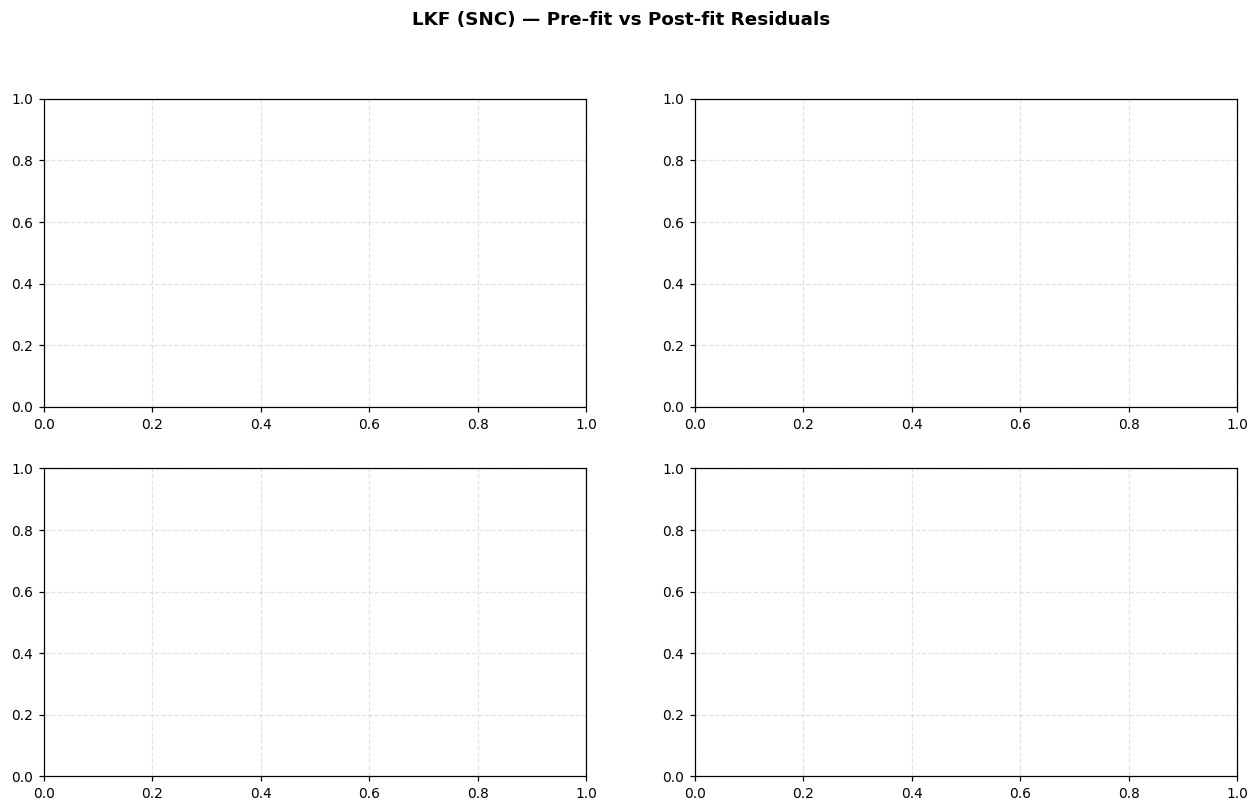

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("LKF (SNC) — Pre-fit vs Post-fit Residuals", fontsize=12, fontweight="bold")

for row, (ds_name, sigma_val, ylabel) in enumerate([
    ("GS1 Range",    float(range_sigma.values) * 1e3,  "Range residual [m]"),
    ("GS1 RangeRate",float(rr_sigma.values)    * 1e6,  "RangeRate residual [mm/s]"),
]):
    scale = 1e3 if row == 0 else 1e6
    t_pre, r_pre, t_post, r_post = resid_from_filter(lkf, ds_name)
    for col, (t_r, r_r, label) in enumerate(
        [(t_pre, r_pre, "Pre-fit"), (t_post, r_post, "Post-fit")]
    ):
        ax = axes[row, col]
        if len(t_r):
            ax.plot(et2dt(t_r), r_r * scale, ".", ms=3, color=COLORS[row*2+col], alpha=0.7)
            ax.axhline(0, color="k", lw=0.6, ls="--")
            ax.axhline( 3 * sigma_val, color="r", lw=0.9, ls="--", alpha=0.7, label="±3σ")
            ax.axhline(-3 * sigma_val, color="r", lw=0.9, ls="--", alpha=0.7)
        ax.set_title(f"{ds_name} — {label}")
        ax.set_ylabel(ylabel); ax.set_xlabel("Calendar Date [UTC]")
        fmt_cal(ax); ax.legend()

plt.tight_layout(); plt.show()


#### Enhanced: LKF (SNC) — State Errors with ±3σ Covariance Bounds


In [7]:
et_meas  = sol_lkf.timestamps
meas_ep  = scb.EpochArray(scb.ArrayWUnits(et_meas, sec), "TDB")
est_pos  = sol_lkf.state_est[:, :3]
est_vel  = sol_lkf.state_est[:, 3:6]

truth_t   = epoch_array.times.values
truth_pos = state_prop_truth.values_array[("position", Orbiter.spice_id)][0]
truth_vel = state_prop_truth.values_array[("velocity", Orbiter.spice_id)][0]
tp_meas   = np.column_stack([np.interp(et_meas, truth_t, truth_pos[:, j]) for j in range(3)])
tv_meas   = np.column_stack([np.interp(et_meas, truth_t, truth_vel[:, j]) for j in range(3)])
err_pos   = est_pos - tp_meas
err_vel   = est_vel - tv_meas

P_list  = sol_lkf.propagate_covariance(meas_ep)
sig_pos = np.array([np.sqrt(np.diag(P)[:3]) for P in P_list])
sig_vel = np.array([np.sqrt(np.diag(P)[3:6]) for P in P_list])
dts     = et2dt(et_meas)

lbl_p = ["Δx [km]",   "Δy [km]",   "Δz [km]"]
lbl_v = ["Δvx [m/s]", "Δvy [m/s]", "Δvz [m/s]"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True)
fig.suptitle("LKF (SNC) — State Errors vs Truth  (±3σ bounds)",
             fontsize=12, fontweight="bold")
for col in range(3):
    ax = axes[0, col]
    ax.plot(dts, err_pos[:, col], "-", lw=1.3, color=COLORS[col], label="Error")
    ax.fill_between(dts, 3*sig_pos[:, col], -3*sig_pos[:, col],
                    alpha=0.20, color=COLORS[col], label="±3σ")
    ax.axhline(0, color="k", lw=0.5, ls="--"); ax.set_ylabel(lbl_p[col])
    if col == 0: ax.legend(fontsize=8)
    fmt_cal(ax); add_hrs_axis(ax, t0_et)

    ax = axes[1, col]
    ax.plot(dts, err_vel[:, col]*1e3, "-", lw=1.3, color=COLORS[col+3])
    ax.fill_between(dts, 3*sig_vel[:, col]*1e3, -3*sig_vel[:, col]*1e3,
                    alpha=0.20, color=COLORS[col+3])
    ax.axhline(0, color="k", lw=0.5, ls="--"); ax.set_ylabel(lbl_v[col])
    ax.set_xlabel("Calendar Date [UTC]"); fmt_cal(ax)
plt.tight_layout(); plt.show()


NameError: name 'sol_lkf' is not defined

#### Enhanced: LKF (SNC) — Covariance Evolution (1-σ components, semilogy)


In [8]:
sig_pos = np.array([np.sqrt(np.diag(P)[:3])  for P in P_list])   # P_list from cell above
sig_vel = np.array([np.sqrt(np.diag(P)[3:6]) for P in P_list])
rss_pos = np.linalg.norm(sig_pos, axis=1)
rss_vel = np.linalg.norm(sig_vel, axis=1)
dts     = et2dt(et_meas)

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
fig.suptitle("LKF (SNC) — Covariance Evolution (1-σ)", fontsize=12, fontweight="bold")
lbl_p = ["σx", "σy", "σz"]; lbl_v = ["σvx", "σvy", "σvz"]

ax = axes[0, 0]
for i in range(3): ax.semilogy(dts, sig_pos[:, i]*1e3, lw=1.5, color=COLORS[i], label=lbl_p[i])
ax.set_ylabel("Pos 1-σ [m]"); ax.legend(); fmt_cal(ax); add_hrs_axis(ax, t0_et)

ax = axes[0, 1]
ax.semilogy(dts, rss_pos*1e3, "k-", lw=2); ax.set_ylabel("Pos RSS 1-σ [m]")
fmt_cal(ax); add_hrs_axis(ax, t0_et)

ax = axes[1, 0]
for i in range(3): ax.semilogy(dts, sig_vel[:, i]*1e6, lw=1.5, color=COLORS[i+3], label=lbl_v[i])
ax.set_ylabel("Vel 1-σ [mm/s]"); ax.set_xlabel("Calendar Date [UTC]"); ax.legend(); fmt_cal(ax)

ax = axes[1, 1]
ax.semilogy(dts, rss_vel*1e6, "k-", lw=2); ax.set_ylabel("Vel RSS 1-σ [mm/s]")
ax.set_xlabel("Calendar Date [UTC]"); fmt_cal(ax)

plt.tight_layout(); plt.show()


NameError: name 'P_list' is not defined

## 3. Process Noise Deep Dive: SNC vs. DMC

### State Noise Compensation (SNC)
- Models uncharacterised forces as **continuous white noise on velocity**.
- Does **not** increase state dimension.
- `Q_cont` is a 3×3 matrix [km²/s⁴] — one spectral density per acceleration axis.
- Typical values: 1e-18 (well-modelled) to 1e-12 (significant unmodelled forces) km²/s⁴.
- Increases covariance between measurements, preventing filter overconfidence.

### Dynamical Model Compensation (DMC)
- Models uncharacterised forces as a **first-order Gauss-Markov (FOGM)** stochastic process.
- The FOGM acceleration `a_fogm` is **part of the state** and is propagated.
- Requires `ForceModelTranslation(first_order_gauss_markov=True, fogm_beta=...)`
- Process noise type: `'DMC'` with `beta=force_model.fogm_beta`.

```python
# SNC — no state augmentation
pn = scb.ProcessNoiseSettings(type='SNC', Q_cont=Q_matrix)

# DMC — augmented state with FOGM acceleration
pn = scb.ProcessNoiseSettings(type='DMC', Q_cont=Q_matrix,
                               beta=force_model.fogm_beta)
```

### When to use which
| Scenario | Recommendation |
|----------|----------------|
| Short arc, well-modelled dynamics | SNC (small Q) |
| Long arc with slow-varying unmodelled forces | DMC (captures temporal correlation) |
| Maneuver estimation during arc | DMC + FOGM |
| Batch filter | Neither (use PFOGM instead) |

### Correlation time and β
In the FOGM model the force autocorrelation decays as $e^{-\beta \Delta t}$.
- Large β (e.g. 1/60 s⁻¹) → force decorrelates in ~1 minute (rapid white-noise-like behaviour)
- Small β (e.g. 1/86400 s⁻¹) → force has memory over ~1 day (slow trend)

Rule of thumb: set β so the correlation time 1/β matches the expected timescale of the
unmodelled perturbation.


## 4. FOGM Dynamics + DMC Process Noise

The **First-Order Gauss-Markov** stochastic acceleration is propagated as part of the state.
It represents an unmodelled force that decays exponentially with characteristic time 1/β.

State vector: $[r_x, r_y, r_z, v_x, v_y, v_z, a_{fx}, a_{fy}, a_{fz}]$

The process noise (DMC) drives the FOGM acceleration component.


In [9]:
# ── spacecraft with FOGM in state ────────────────────────────────
sc_fogm, pos_fogm, vel_fogm = make_ref_sc('Orbiter_FOGM', -2002,
                                            delta_pos_km, delta_vel_kms)

# Initial FOGM acceleration (zero — no a-priori knowledge of unmodelled force)
a0_fogm = scb.ArrayWFrame(np.zeros(3), km/sec**2, J2000)

# Slight perturbation to a_fogm initial value
da_fogm = scb.ArrayWUnits(np.array([rnd.normal(0, 1e-12)]*3), km/sec**2)
a0_fogm_pert = scb.ArrayWFrame(a0_fogm.quantity + da_fogm, J2000)

state_fogm = (
    scb.StateDefinition()
    .position(sc_fogm, pos_fogm)
    .velocity(sc_fogm, vel_fogm)
    .param('a_fogm', sc_fogm, a0_fogm_pert, dynamics='dynamic')
)
sv_fogm = scb.StateArray(epoch=epoch_0, origin=origin, state=state_fogm)

beta_fogm = np.array([1/3600, 1/3600, 1/3600])  # 1-hr correlation time

fm_fogm = scb.ForceModelTranslation(
    primary_body             = sc_fogm,
    third_bodies             = third_bodies,
    cannonball_SRP           = True,
    first_order_gauss_markov = True,
    fogm_beta                = beta_fogm,
)
prop_fogm = scb.Propagator(
    primary_body = sc_fogm, state_vector = sv_fogm,
    tspan        = epoch_array, force_models = fm_fogm)

# ── extended covariance (6 + 3 FOGM) ────────────────────────────
a_sig    = scb.ArrayWUnits(1e-10, km/sec**2)
P0_fogm  = scb.CovarianceMatrix(
    [pos_sig]*3 + [vel_sig]*3 + [a_sig]*3,
    epoch_array[1], from_list=True)

# ── DMC process noise ────────────────────────────────────────────
Q_dmc_diag = scb.ArrayWUnits(1e-12**2, km**2 * sec**-4)
Q_dmc_cont = scb.CovarianceMatrix([Q_dmc_diag]*3, epoch_array[0], from_list=True)
pn_dmc     = scb.ProcessNoiseSettings(type='DMC', Q_cont=Q_dmc_cont, beta=beta_fogm)

# ── measurement models with FOGM state definition ────────────────
Range_GS1_fogm = scb.RangeIdeal('GS1 Range FOGM', GS1,
                                  sigma=range_sigma, state_definition=state_fogm)
RR_GS1_fogm    = scb.RangeRateIdeal('GS1 RR FOGM', GS1,
                                     sigma=rr_sigma, state_definition=state_fogm)
meas_fogm = scb.MeasurementSpec.from_dict([
    {'model': Range_GS1_fogm, 'observed_meas': obs_range, 'dataset_name': 'GS1 Range'},
    {'model': RR_GS1_fogm,    'observed_meas': obs_rr,    'dataset_name': 'GS1 RangeRate'},
])

# ── LKF with DMC ─────────────────────────────────────────────────
ref_spk_fogm = 'data/kernels/scenario/seq_orbiter_ref_fogm.bsp'
if os.path.isfile(ref_spk_fogm): os.remove(ref_spk_fogm)

lkf_fogm = scb.LKF(
    propagator   = prop_fogm,
    settings     = scb.FilterSettings(
        initial_covariance = P0_fogm,
        process_noise      = pn_dmc,
        output             = scb.OutputSettings(metadata={'filter':'LKF-DMC-FOGM'}),
    ),
    measurements = meas_fogm,
    traj_name    = 'seq_orbiter_ref_fogm.bsp',
)
print("Running LKF with FOGM dynamics + DMC process noise ...")
sol_fogm, ni_fogm, conv_fogm = lkf_fogm.fit(
    max_iterations=5, convergence_threshold=1e-6, verbose=True,
    traj_name='seq_orbiter_ref.bsp',
)
print(f"Converged: {conv_fogm} after {ni_fogm} iterations")

# Plot FOGM parameter estimates
scb.Plotting.get_fig_handle(
    scb.Plotting.plot_parameters_errors(
        sol_fogm, orbiter_traj_true, epoch_array, 3,
        title='FOGM Acceleration Estimates'
    )
)
plt.show()


NameError: name 'dry_mass' is not defined

#### Enhanced: FOGM+DMC — Stochastic Acceleration Time Series

The three FOGM acceleration components (x, y, z in J2000) estimated by the filter as
a function of time.  The state deviation is extracted via `map_state_deviation_to_epoch()`
and the last three elements are the acceleration corrections (indices 6, 7, 8).

A well-identified unmodelled force should appear as a coherent signature, while pure
noise yields random small values around zero.


In [10]:
# Extract FOGM acceleration evolution from residual solution
et_fogm      = sol_fogm.timestamps
est_params_f = sol_fogm.state_est[:, 6:9] if sol_fogm.state_est is not None else None

# est_params_f contains FOGM acc corrections per epoch (shape: N×3)
if est_params_f is not None:
    a_fogm_est = est_params_f   # (N, 3) in km/s²
    dts_f = et2dt(et_fogm)

    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    fig.suptitle("FOGM+DMC — Estimated Stochastic Acceleration Components",
                 fontsize=12, fontweight="bold")
    comp_labels = ["a_x [nm/s²]", "a_y [nm/s²]", "a_z [nm/s²]"]
    for i in range(3):
        axes[i].plot(dts_f, a_fogm_est[:, i] * 1e9, "-", lw=1.2, color=COLORS[i])
        axes[i].axhline(0, color="k", lw=0.5, ls="--")
        axes[i].set_ylabel(comp_labels[i]); fmt_cal(axes[i]); add_hrs_axis(axes[i], t0_et)
    axes[2].set_xlabel("Calendar Date [UTC]")
    plt.tight_layout(); plt.show()
else:
    print("FOGM acceleration parameters not available in state_est — check FOGM state setup.")


NameError: name 'sol_fogm' is not defined

## 5. SRIF Sequential Filter

The **Square-Root Information Filter (SRIF)** is the numerically most stable sequential algorithm.
Instead of propagating the covariance **P**, it propagates the square root of the information
matrix **R = P⁻¹**, avoiding the numerical issues associated with covariance inversion.

SRIF is preferred when:
- The state dimension is large (many parameters)
- Long arcs with many measurements accumulate numerical error in P
- Near-singular covariance matrices arise (highly correlated parameters)

API is identical to LKF — just swap `scb.LKF` for `scb.SRIF`.


In [11]:
# ── SRIF — reuse the same reference setup as LKF ────────────────
sc_srif, pos_srif, vel_srif = make_ref_sc('Orbiter_SRIF', -2003,
                                            delta_pos_km, delta_vel_kms)
state_srif = scb.StateDefinition.from_components([
    ('position', 3, 'estimated', 'dynamic', sc_srif, pos_srif),
    ('velocity', 3, 'estimated', 'dynamic', sc_srif, vel_srif),
])
sv_srif   = scb.StateArray(epoch=epoch_0, origin=origin, state=state_srif)
fm_srif   = scb.ForceModelTranslation(primary_body=sc_srif,
                                       third_bodies=third_bodies, cannonball_SRP=True)
prop_srif = scb.Propagator(primary_body=sc_srif, state_vector=sv_srif,
                            tspan=epoch_array, force_models=fm_srif)

meas_srif = scb.MeasurementSpec.many(
    scb.MeasurementSpec(model=Range_GS1,     observed_meas=obs_range,
                        dataset_name='GS1 Range'),
    scb.MeasurementSpec(model=RangeRate_GS1, observed_meas=obs_rr,
                        dataset_name='GS1 RangeRate'),
)

ref_spk_srif = 'data/kernels/scenario/seq_orbiter_ref_srif.bsp'
if os.path.isfile(ref_spk_srif): os.remove(ref_spk_srif)

srif = scb.SRIF(
    propagator   = prop_srif,
    settings     = scb.FilterSettings(
        initial_covariance = P0,
        process_noise      = pn_snc,
        output             = scb.OutputSettings(metadata={'filter':'SRIF-SNC'}),
    ),
    measurements = meas_srif,
    traj_name    = 'seq_orbiter_ref_srif.bsp',
)
print("Running SRIF ...")
sol_srif, ni_srif, conv_srif = srif.fit(
    max_iterations=5, convergence_threshold=1e-6, verbose=True,
    traj_name='seq_orbiter_ref.bsp',
)
print(f"SRIF converged: {conv_srif} after {ni_srif} iterations")


NameError: name 'dry_mass' is not defined

## 6. RTS Smoother

The **Rauch-Tung-Striebel (RTS) smoother** runs a backward pass after the forward Kalman filter
to refine estimates at *earlier* epochs using measurements from *later* epochs.

- The forward filter is causal: at $t_k$ it uses only measurements $t \leq t_k$.
- The smoother is acausal: at $t_k$ it uses **all** measurements in the arc.

Enable it by passing `if_sequential_smooth=True` to `filter.fit()`.
The smoothed solution is stored in `solution.deviation_smooth` and `solution.covariance_smooth`.

**When to use:** post-processing after all data are collected.
**Not applicable for:** real-time navigation (forward-only).


In [12]:
# ── LKF + RTS smoother ───────────────────────────────────────────
sc_sm, pos_sm, vel_sm = make_ref_sc('Orbiter_Smooth', -2004,
                                     delta_pos_km, delta_vel_kms)
state_sm = scb.StateDefinition.from_components([
    ('position', 3, 'estimated', 'dynamic', sc_sm, pos_sm),
    ('velocity', 3, 'estimated', 'dynamic', sc_sm, vel_sm),
])
sv_sm   = scb.StateArray(epoch=epoch_0, origin=origin, state=state_sm)
fm_sm   = scb.ForceModelTranslation(primary_body=sc_sm,
                                     third_bodies=third_bodies, cannonball_SRP=True)
prop_sm = scb.Propagator(primary_body=sc_sm, state_vector=sv_sm,
                          tspan=epoch_array, force_models=fm_sm)

meas_sm = scb.MeasurementSpec.many(
    scb.MeasurementSpec(model=Range_GS1,     observed_meas=obs_range,
                        dataset_name='GS1 Range'),
    scb.MeasurementSpec(model=RangeRate_GS1, observed_meas=obs_rr,
                        dataset_name='GS1 RangeRate'),
)

ref_spk_sm = 'data/kernels/scenario/seq_orbiter_ref_smooth.bsp'
if os.path.isfile(ref_spk_sm): os.remove(ref_spk_sm)

lkf_sm = scb.LKF(
    propagator   = prop_sm,
    settings     = scb.FilterSettings(
        initial_covariance = P0,
        process_noise      = pn_snc,
        output             = scb.OutputSettings(metadata={'filter':'LKF-SNC-Smooth'}),
    ),
    measurements = meas_sm,
    traj_name    = 'seq_orbiter_ref_smooth.bsp',
)
print("Running LKF + RTS smoother ...")
sol_sm, ni_sm, conv_sm = lkf_sm.fit(
    max_iterations       = 5,
    convergence_threshold= 1e-6,
    verbose              = True,
    traj_name            = 'seq_orbiter_ref.bsp',
    if_sequential_smooth = True,    # ← enable RTS smoother
)
print(f"LKF+Smoother converged: {conv_sm} after {ni_sm} iterations")

# ── compare filter vs smoother state errors ────────────────────
scb.Plotting.get_fig_handle(
    scb.Plotting.plot_state_errors(
        sol_sm, orbiter_traj_true, epoch_array, 3,
        title='LKF + RTS Smoother — State Errors'
    )
)
plt.show()


NameError: name 'dry_mass' is not defined

#### Enhanced: RTS Smoother — Forward Filter vs Smoothed Covariance Comparison

The smoother runs a backward pass over the measurement arc, incorporating future
information into earlier estimates.  Its covariance is therefore always ≤ the
forward filter covariance.

This 2-panel plot shows the position 1-σ RSS for both the forward filter and
the smoothed solution on the same semilogy axis — the gap between them quantifies
how much the smoother improves the estimate at earlier epochs.


In [13]:
et_sm    = sol_sm.timestamps
meas_ep_sm = scb.EpochArray(scb.ArrayWUnits(et_sm, sec), "TDB")

# Forward filter covariance (using LKF with smoother disabled = sol_lkf)
P_fwd_list = sol_lkf.propagate_covariance(meas_ep_sm)
rss_fwd    = np.array([np.sqrt(np.sum(np.diag(P)[:3])) for P in P_fwd_list])

# Smoother covariance
P_sm_list  = sol_sm.propagate_covariance(meas_ep_sm)
rss_sm     = np.array([np.sqrt(np.sum(np.diag(P)[:3])) for P in P_sm_list])

dts_sm = et2dt(et_sm)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("RTS Smoother — Forward Filter vs Smoothed Covariance",
             fontsize=12, fontweight="bold")

for ax, rss_f, rss_s, title in [
    (ax1, rss_fwd,  rss_sm,  "Position 1-σ RSS [km]  (semilogy)"),
    (ax2, rss_fwd * 1e3, rss_sm * 1e3, "Position 1-σ RSS [m]  (linear)"),
]:
    ax.semilogy(dts_sm, rss_f, "b-",  lw=1.5, label="Forward filter (LKF)")
    ax.semilogy(dts_sm, rss_s, "r--", lw=1.5, label="Smoothed (RTS)")
    ax.set_title(title); ax.set_xlabel("Calendar Date [UTC]")
    ax.legend(); fmt_cal(ax); add_hrs_axis(ax, t0_et)

plt.tight_layout(); plt.show()

ratio = rss_sm.mean() / rss_fwd.mean()
print(f"Mean smoothed/forward RSS ratio: {ratio:.3f}  (< 1 means smoother improved estimate)")


NameError: name 'sol_sm' is not defined

## 7. Multi-Leg OD with MissionSequence

Real missions often have **maneuvers** (delta-v burns) during the tracking arc.
A `MissionSequence` chains together trajectory legs separated by burn events.

### Structure
```
Leg 1 → [Impulsive Burn] → Leg 2 → [Impulsive Burn] → Leg 3 → ...
```

Each leg has its own:
- State definition (position, velocity, optional parameters)
- Propagator (can include different force models)
- Epoch span

The filter processes all legs continuously, propagating the STM across burn events.

### Key classes
- `MissionSequence.addLeg(name, duration, state_model, propagator, dt)`
- `MissionSequence.addBurn(name, burn_model, propagator)`
- `ImpulsiveBurn(dv_magnitude, dv_unit_vector)` — instantaneous ΔV


In [14]:
# ── multi-leg: 2 legs + 1 impulsive burn midway ──────────────────
sc_ms = scb.Spacecraft('Orbiter_MS', -2005, dry_mass+fuel_mass, area, cr)

# Epoch setup — split the arc in two equal halves
time_mid    = scb.SpiceManager.jd2et(2461809.72995654 + 1/3 + 1.5)  # midpoint
leg_period  = scb.ArrayWUnits(float(time_mid - time_0), sec)         # half-arc length
leg_dt      = scb.ArrayWUnits(dt_step, sec)

pos_ms = scb.ArrayWFrame(pos_0.quantity + scb.ArrayWUnits(delta_pos_km, km), frame)
vel_ms = scb.ArrayWFrame(vel_0.quantity + scb.ArrayWUnits(delta_vel_kms, km/sec), frame)

# ── Leg 1 state definition ───────────────────────────────────────
leg1_state_def = [
    ('position', 3, 'estimated', 'dynamic', sc_ms, pos_ms),
    ('velocity', 3, 'estimated', 'dynamic', sc_ms, vel_ms),
]
leg1_model = scb.StateArray(
    epoch=epoch_0, origin=origin,
    state=scb.StateDefinition.from_components(leg1_state_def)
)

# ── Leg 2 state (pos/vel inherit from burn output — NaN placeholders) ─
leg2_state_def = [
    ('position', 3, 'estimated', 'dynamic', sc_ms,
     scb.ArrayWFrame(scb.ArrayWUnits(np.full(3, np.nan), km), frame)),
    ('velocity', 3, 'estimated', 'dynamic', sc_ms,
     scb.ArrayWFrame(scb.ArrayWUnits(np.full(3, np.nan), km/sec), frame)),
]
leg2_model = scb.StateArray(
    epoch=scb.EpochArray(np.full(1, np.nan), time_frame='TDB'),
    origin=origin,
    state=scb.StateDefinition.from_components(leg2_state_def)
)

# ── force models ──────────────────────────────────────────────────
fm_ms = scb.ForceModelTranslation(
    primary_body=sc_ms, third_bodies=third_bodies, cannonball_SRP=True)

prop_leg1 = scb.Propagator(primary_body=sc_ms, state_vector=leg1_model,
                            tspan=epoch_array, force_models=fm_ms)
prop_leg2 = scb.Propagator(primary_body=sc_ms, state_vector=leg2_model,
                            tspan=epoch_array, force_models=fm_ms)

# ── impulsive burn model (1 m/s in x-direction) ───────────────────
burn = scb.ImpulsiveBurn(
    dv_magnitude  = scb.ArrayWUnits(np.array([1e-3]), km/sec),   # 1 m/s
    dv_unit_vector= scb.ArrayWUnits(np.array([1.0, 0.0, 0.0]), None),
)

# ── assemble MissionSequence ─────────────────────────────────────
MS = scb.MissionSequence('SeqDemo')
MS.addLeg( 'Leg1',  leg_period, leg1_model, prop_leg1, leg_dt)
MS.addBurn('DVBurn', burn,                  prop_leg1)
MS.addLeg( 'Leg2',  leg_period, leg2_model, prop_leg2, leg_dt)

# ── propagate the full sequence ───────────────────────────────────
print("Propagating MissionSequence ...")
Scenario = MS.propagate()

# Save sequence trajectory
ms_spk = 'data/kernels/scenario/seq_orbiter_ms_true.bsp'
if os.path.isfile(ms_spk): os.remove(ms_spk)
traj_ms = scb.Trajectory(leg_array=Scenario)
traj_ms.write_to_spk(ms_spk)
traj_ms.add_STMs(Scenario.total_STMs)
print(f"MissionSequence trajectory saved.")

# ── generate measurements on the sequence trajectory ─────────────
Range_GS1_ms = scb.RangeIdeal('GS1 Range MS', GS1,
                                sigma=range_sigma, sequence_definition=MS)
RR_GS1_ms    = scb.RangeRateIdeal('GS1 RRate MS', GS1,
                                   sigma=rr_sigma, sequence_definition=MS)

Range_GS1_ms.write_observed_measurements(
    target=sc_ms, epoch_array=Scenario.total_epochsTDB, noisy=True,
    file_name='seq_range_MS')
RR_GS1_ms.write_observed_measurements(
    target=sc_ms, epoch_array=Scenario.total_epochsTDB, noisy=True,
    file_name='seq_rr_MS')

obs_range_ms = Range_GS1_ms.observed_measurements(
    file_name='data/measurements/radiometric/seq_range_MS.json',
    meas_name='meas_ideal', units=km)
obs_rr_ms    = RR_GS1_ms.observed_measurements(
    file_name='data/measurements/radiometric/seq_rr_MS.json',
    meas_name='meas_ideal', units=km/sec)

print(f"Multi-leg measurements: Range {len(obs_range_ms[2])}, RRate {len(obs_rr_ms[2])}")


NameError: name 'dry_mass' is not defined

In [15]:
# ── LKF on MissionSequence ───────────────────────────────────────
meas_ms = scb.MeasurementSpec.many(
    scb.MeasurementSpec(model=Range_GS1_ms, observed_meas=obs_range_ms,
                        dataset_name='GS1 Range MS'),
    scb.MeasurementSpec(model=RR_GS1_ms,   observed_meas=obs_rr_ms,
                        dataset_name='GS1 RRate MS'),
)

Q_ms   = scb.CovarianceMatrix([scb.ArrayWUnits(1e-9**2, km**2*sec**-4)]*3,
                                epoch_array[0], from_list=True)
pn_ms  = scb.ProcessNoiseSettings(type='SNC', Q_cont=Q_ms)

ref_spk_ms = 'data/kernels/scenario/seq_orbiter_ref_ms.bsp'
if os.path.isfile(ref_spk_ms): os.remove(ref_spk_ms)

lkf_ms = scb.LKF(
    propagator   = prop_leg1,          # MissionSequence handles leg routing internally
    settings     = scb.FilterSettings(
        initial_covariance = P0,
        process_noise      = pn_ms,
        output             = scb.OutputSettings(metadata={'filter':'LKF-MissionSequence'}),
    ),
    measurements = meas_ms,
    traj_name    = 'seq_orbiter_ref_ms.bsp',
)
print("Running LKF on MissionSequence ...")
sol_ms, ni_ms, conv_ms = lkf_ms.fit(
    max_iterations=5, convergence_threshold=1e-6, verbose=True,
    traj_name='seq_orbiter_ref.bsp',
)
print(f"MS filter converged: {conv_ms} after {ni_ms} iterations")


NameError: name 'Range_GS1_ms' is not defined

## 8. Consider Parameters

A **consider parameter** is a physical quantity that:
1. Has significant uncertainty and affects the measurements (it is *observable*).
2. Is **not** solved for — it is held at its reference value during the solve.
3. Its uncertainty is carried forward into the state covariance (conservative covariance inflation).

This is useful when a parameter cannot be resolved from the available data but ignoring its
uncertainty would produce an over-optimistic covariance.

```python
# Estimated: filter updates this parameter's value
.param('eta_srp', sc, value, estimation='estimated', dynamics='static')

# Considered: uncertainty propagated but value not updated
.param('eta_srp', sc, value, estimation='considered', dynamics='static')
```

Typical consider parameters in OD:
- Ground station position error
- Transponder delay calibration
- SRP scale factor (when observable evidence is weak)
- Range bias


In [16]:
# ── sequential OD with η_SRP as a consider parameter ────────────
sc_cp, pos_cp, vel_cp = make_ref_sc('Orbiter_Consider', -2006,
                                     delta_pos_km, delta_vel_kms)

eta_consider = scb.ArrayWFrame(scb.ArrayWUnits(np.array([1.0]), None), None)

state_cp = (
    scb.StateDefinition()
    .position(sc_cp, pos_cp)
    .velocity(sc_cp, vel_cp)
    .param('eta_srp', sc_cp, eta_consider,
           estimation='considered', dynamics='static')   # ← considered, not estimated
)
sv_cp   = scb.StateArray(epoch=epoch_0, origin=origin, state=state_cp)
fm_cp   = scb.ForceModelTranslation(primary_body=sc_cp,
                                     third_bodies=third_bodies, cannonball_SRP=True)
prop_cp = scb.Propagator(primary_body=sc_cp, state_vector=sv_cp,
                          tspan=epoch_array, force_models=fm_cp)

eta_sig  = scb.ArrayWUnits(np.array([0.05]), None)  # ±5% uncertainty on η
P0_cp    = scb.CovarianceMatrix(
    [pos_sig]*3 + [vel_sig]*3 + [eta_sig],
    epoch_array[1], from_list=True)

Range_GS1_cp = scb.RangeIdeal('GS1 Range CP', GS1,
                                sigma=range_sigma, state_definition=state_cp)
RR_GS1_cp    = scb.RangeRateIdeal('GS1 RR CP', GS1,
                                   sigma=rr_sigma, state_definition=state_cp)

meas_cp = scb.MeasurementSpec.from_dict([
    {'model': Range_GS1_cp, 'observed_meas': obs_range, 'dataset_name': 'GS1 Range'},
    {'model': RR_GS1_cp,    'observed_meas': obs_rr,    'dataset_name': 'GS1 RR'},
])

ref_spk_cp = 'data/kernels/scenario/seq_orbiter_ref_cp.bsp'
if os.path.isfile(ref_spk_cp): os.remove(ref_spk_cp)

lkf_cp = scb.LKF(
    propagator   = prop_cp,
    settings     = scb.FilterSettings(
        initial_covariance = P0_cp,
        process_noise      = pn_snc,
        output             = scb.OutputSettings(metadata={'filter':'LKF-Consider-eta'}),
    ),
    measurements = meas_cp,
    traj_name    = 'seq_orbiter_ref_cp.bsp',
)
print("Running LKF with consider parameter η_SRP ...")
sol_cp, ni_cp, conv_cp = lkf_cp.fit(
    max_iterations=5, convergence_threshold=1e-6, verbose=True,
    traj_name='seq_orbiter_ref.bsp',
)
print(f"\nConverged: {conv_cp}  (note: covariance is inflated by η uncertainty)")


NameError: name 'dry_mass' is not defined

## 9. Measurement Editing

Sequential filters can apply measurement editing via `FilterSettings`:

```python
# Chi-squared editing (most common)
settings = scb.FilterSettings(
    ...
    editing_method = 'chi_squared',
    editing_kwargs = {'sigma_scale': 3.0},
)

# Interactive lasso (requires interactive matplotlib backend)
settings = scb.FilterSettings(
    ...
    editing_method = 'lasso',
    editing_kwargs = {'sigma_scale': 3.0, 'preview': True},
)

# Date-range exclusion
settings = scb.FilterSettings(
    ...
    editing_method = 'date_range',
    editing_kwargs = {'start': t_start_et, 'end': t_end_et},
)
```

Chi-squared editing is the recommended default for operational OD.
A 3-σ threshold corresponds to flagging ~0.3% of good data as outliers (false alarm rate).


In [17]:
# ── LKF with chi-squared measurement editing ─────────────────────
sc_ed2, pos_ed2, vel_ed2 = make_ref_sc('Orbiter_EditSeq', -2007,
                                         delta_pos_km, delta_vel_kms)
state_ed2 = scb.StateDefinition.from_components([
    ('position', 3, 'estimated', 'dynamic', sc_ed2, pos_ed2),
    ('velocity', 3, 'estimated', 'dynamic', sc_ed2, vel_ed2),
])
sv_ed2   = scb.StateArray(epoch=epoch_0, origin=origin, state=state_ed2)
fm_ed2   = scb.ForceModelTranslation(primary_body=sc_ed2,
                                      third_bodies=third_bodies, cannonball_SRP=True)
prop_ed2 = scb.Propagator(primary_body=sc_ed2, state_vector=sv_ed2,
                           tspan=epoch_array, force_models=fm_ed2)

# Inject outliers in range
obs_range_bad = (obs_range[0], obs_range[1], obs_range[2].copy())
bad_idx = np.random.RandomState(7).choice(len(obs_range[2]), 8, replace=False)
obs_range_bad[2][bad_idx] += np.random.RandomState(7).uniform(-30, 30, 8)
print(f"Outliers injected at {len(bad_idx)} range epochs.")

meas_ed2 = scb.MeasurementSpec.many(
    scb.MeasurementSpec(model=Range_GS1,     observed_meas=obs_range_bad,
                        dataset_name='GS1 Range (outliers)'),
    scb.MeasurementSpec(model=RangeRate_GS1, observed_meas=obs_rr,
                        dataset_name='GS1 RangeRate'),
)

ref_spk_ed2 = 'data/kernels/scenario/seq_orbiter_ref_ed2.bsp'
if os.path.isfile(ref_spk_ed2): os.remove(ref_spk_ed2)

lkf_ed2 = scb.LKF(
    propagator   = prop_ed2,
    settings     = scb.FilterSettings(
        initial_covariance = P0,
        process_noise      = pn_snc,
        editing_method     = 'chi_squared',
        editing_kwargs     = {'sigma_scale': 3.0},
        output             = scb.OutputSettings(metadata={'filter':'LKF-chi2edit'}),
    ),
    measurements = meas_ed2,
    traj_name    = 'seq_orbiter_ref_ed2.bsp',
)
print("Running LKF with chi-squared editing ...")
sol_ed2, ni_ed2, conv_ed2 = lkf_ed2.fit(
    max_iterations=5, convergence_threshold=1e-6, verbose=True,
    traj_name='seq_orbiter_ref.bsp',
)
print(f"Converged: {conv_ed2}")


NameError: name 'dry_mass' is not defined

## 10. Solution Saving and Full Analysis

`SolutionOD` (returned by `filter.fit()`) is the primary result container.

### Accessing results
| Attribute/Method | Description |
|-----------------|-------------|
| `solution.timestamps` | Measurement epoch times [s TDB] |
| `solution.estimated_trajectory(epochs)` | (pos, vel, params) at requested epochs |
| `solution.propagate_covariance(epochs)` | List of P matrices |
| `solution.propagate_state(epochs)` | List of StateArray objects |
| `solution.map_state_deviation_to_epoch()` | δx vector at epoch_0 |
| `solution.deviation_smooth` | RTS-smoothed deviations (if smoother enabled) |

### Saving to files
Configure `OutputSettings` before running the filter:
```python
scb.OutputSettings(
    solution_output_path = 'results/',
    solution_output_name = 'seq_od_run1',
    metadata             = {'version': '1.0'},
)
```


In [18]:
# ── full solution analysis using the LKF result ──────────────────
solution = sol_lkf

# ── 1. State deviation at epoch_0 ────────────────────────────────
dev_0 = solution.map_state_deviation_to_epoch()
print("Estimated state correction at epoch_0:")
print(f"  Δpos [km]   : {dev_0[:3]}")
print(f"  Δvel [km/s] : {dev_0[3:6]}")

# ── 2. Estimated trajectory ───────────────────────────────────────
est_pos = solution.state_est[:, :3]
est_vel = solution.state_est[:, 3:6]
print(f"\nEstimated trajectory: {est_pos.shape[0]} epochs computed.")

# ── 3. Post-fit residuals ─────────────────────────────────────────
scb.Plotting.get_fig_handle(
    scb.Plotting.plot_postfits_scatter(
        solution, epoch_array, lkf.measurement_data.dataset_names, 3
    )
)

# ── 4. Covariance evolution (inside arc) ─────────────────────────
t_arc_start = float(solution.timestamps[0])
t_arc_end   = float(solution.timestamps[-1])
t_inside    = np.linspace(t_arc_start, t_arc_end, 40)
ep_inside   = scb.EpochArray(scb.ArrayWUnits(t_inside, sec), 'TDB')
P_inside    = solution.propagate_covariance(ep_inside)
pos_1sig    = np.array([np.sqrt(np.diag(P)[:3]) for P in P_inside])
rss_in      = np.linalg.norm(pos_1sig, axis=1)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot((t_inside - t_arc_start)/3600, rss_in, 'b-', lw=1.5,
             label='Pos 1-σ RSS')
axes[0].set_ylabel('Position σ [km]')
axes[0].set_title('LKF — Covariance and State Error Evolution')
axes[0].legend(); axes[0].grid(True, alpha=0.4)

if est_pos is not None:
    truth_t   = epoch_array.times.values
    truth_pos = state_prop_truth.values_array[("position", Orbiter.spice_id)][0]
    tp_meas   = np.column_stack([
        np.interp(solution.timestamps, truth_t, truth_pos[:, j]) for j in range(3)
    ])
    err_norm = np.linalg.norm(est_pos - tp_meas, axis=1)
    axes[1].plot((solution.timestamps - solution.timestamps[0])/3600,
                 err_norm, 'r-', lw=1.5, label='|est_pos - truth| [km]')
    axes[1].set_ylabel('Position error [km]')
    axes[1].set_xlabel('Time [hr]')
    axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


NameError: name 'sol_lkf' is not defined

#### Enhanced: Final Covariance Corner Plot (LKF, pos + vel, 6×6)


In [19]:
ep_final_lkf = scb.EpochArray(scb.ArrayWUnits(np.array([sol_lkf.timestamps[-1]]), sec), "TDB")
P_final_lkf  = sol_lkf.propagate_covariance(ep_final_lkf)[0][:6, :6]
labels6 = ["x [km]", "y [km]", "z [km]", "vx [km/s]", "vy [km/s]", "vz [km/s]"]
fig = corner_cov(P_final_lkf, labels6, title="LKF (SNC) — Final State Covariance (6×6)",
                  figsize=(9, 8))
plt.show()


NameError: name 'sol_lkf' is not defined

#### Enhanced: Covariance Propagation Beyond the Arc (Calendar Date)


In [20]:
t_start = float(sol_lkf.timestamps[0])
t_end   = float(sol_lkf.timestamps[-1])
t_extra = np.linspace(t_end, t_end + 6 * 3600, 25)
t_all   = np.concatenate([sol_lkf.timestamps, t_extra])

ep_all  = scb.EpochArray(scb.ArrayWUnits(t_all, sec), "TDB")
P_all   = sol_lkf.propagate_covariance(ep_all)
rss_all = np.array([np.sqrt(np.sum(np.diag(P)[:3])) for P in P_all])
dts_all = et2dt(t_all)
n_arc   = len(sol_lkf.timestamps)

dts_bnd = et2dt([t_start, t_end])
fig, ax = plt.subplots(figsize=(12, 5))
ax.axvspan(dts_bnd[0], dts_bnd[1], alpha=0.12, color="green", label="Measurement arc")
ax.axvline(dts_bnd[1], color="green", lw=1.2, ls="--", label="Arc end")
ax.semilogy(dts_all[:n_arc],    rss_all[:n_arc]    * 1e3, "b.-", ms=4, lw=1.2, label="Inside arc")
ax.semilogy(dts_all[n_arc-1:],  rss_all[n_arc-1:]  * 1e3, "r.-", ms=4, lw=1.2, label="After arc")
ax.set_xlabel("Calendar Date [UTC]"); ax.set_ylabel("Position 1-σ RSS [m]")
ax.set_title("LKF (SNC) — Covariance Propagation Beyond the Arc", fontweight="bold")
ax.legend(); fmt_cal(ax); add_hrs_axis(ax, t0_et)
plt.tight_layout(); plt.show()


NameError: name 'sol_lkf' is not defined

## Summary

This notebook demonstrated the **complete sequential OD workflow** in Scarabaeus:

| Step | Class/Method | Notes |
|------|-------------|-------|
| LKF + SNC | `scb.LKF` + `ProcessNoiseSettings(type='SNC')` | Basic sequential filter |
| SNC tuning | `Q_cont` [km²/s⁴] | Set to expected unmodelled acc² |
| DMC (FOGM) | `ForceModelTranslation(first_order_gauss_markov=True)` | Temporal correlation |
| SRIF | `scb.SRIF` | Numerically stable square-root |
| RTS Smoother | `filter.fit(if_sequential_smooth=True)` | Backward pass |
| Multi-leg | `scb.MissionSequence` + `addLeg / addBurn` | Maneuver-spanning arcs |
| Consider params | `.param(..., estimation='considered')` | Covariance inflation only |
| Measurement editing | `FilterSettings(editing_method='chi_squared')` | 3-σ outlier rejection |
| Solution analysis | `.estimated_trajectory()`, `.propagate_covariance()` | State + covariance |

**See also:** `OD_Batch_Demo.ipynb` for the full batch filter catalogue.
